In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [2]:
df = pd.read_csv("bank.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
print(df.columns.tolist())

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


In [5]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
print(df["deposit"].value_counts())
print()
print(df["deposit"].value_counts(normalize=True) * 100)

deposit
no     5873
yes    5289
Name: count, dtype: int64

deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64


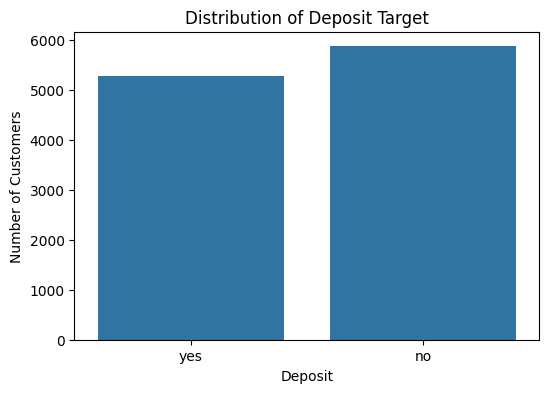

In [8]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="deposit")

plt.title("Distribution of Deposit Target")
plt.xlabel("Deposit")
plt.ylabel("Number of Customers")

plt.show()

In [9]:
X = df.drop("deposit", axis=1)
y = df["deposit"]

In [10]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (11162, 16)
Target shape: (11162,)


In [11]:
y = y.map({"no": 0, "yes": 1})

In [12]:
print(y.value_counts())
print(y.head())

deposit
0    5873
1    5289
Name: count, dtype: int64
0    1
1    1
2    1
3    1
4    1
Name: deposit, dtype: int64


In [13]:
numerical_features = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

categorical_features = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]

In [14]:
print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))
print("Total:", len(numerical_features) + len(categorical_features))

Number of numerical features: 7
Number of categorical features: 9
Total: 16


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [18]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [20]:
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (8929, 16)
Processed training shape: (8929, 51)
Original testing shape: (2233, 16)
Processed testing shape: (2233, 51)


In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("bank.csv")

print("=" * 60)
print("1. DATASET INFORMATION")
print("=" * 60)

print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())


# ============================================================
# 2. DATA TYPES
# ============================================================

print("\n" + "=" * 60)
print("2. DATA TYPES")
print("=" * 60)

print(df.dtypes)


# ============================================================
# 3. MISSING VALUES
# ============================================================

print("\n" + "=" * 60)
print("3. MISSING VALUES")
print("=" * 60)

missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal missing values:", missing_values.sum())


# ============================================================
# 4. DUPLICATE ROWS
# ============================================================

print("\n" + "=" * 60)
print("4. DUPLICATE ROWS")
print("=" * 60)

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)


# ============================================================
# 5. TARGET DISTRIBUTION
# ============================================================

print("\n" + "=" * 60)
print("5. TARGET DISTRIBUTION")
print("=" * 60)

print("\nTarget value counts:")
print(df["deposit"].value_counts())

print("\nTarget percentages:")
print(
    (df["deposit"].value_counts(normalize=True) * 100)
    .round(2)
)


# ============================================================
# 6. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop("deposit", axis=1)
y = df["deposit"].map({
    "no": 0,
    "yes": 1
})

print("\n" + "=" * 60)
print("6. FEATURES AND TARGET")
print("=" * 60)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nNumber of input features:", X.shape[1])

print("\nTarget after encoding:")
print(y.value_counts())


# ============================================================
# 7. DEFINE NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

numerical_features = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

categorical_features = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]

print("\n" + "=" * 60)
print("7. FEATURE TYPES")
print("=" * 60)

print("Numerical features:")
print(numerical_features)
print("Number of numerical features:", len(numerical_features))

print("\nCategorical features:")
print(categorical_features)
print("Number of categorical features:", len(categorical_features))

print("\nTotal features:",
      len(numerical_features) + len(categorical_features))


# ============================================================
# 8. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 60)
print("8. TRAIN / TEST SPLIT")
print("=" * 60)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTraining target percentages:")
print(
    (y_train.value_counts(normalize=True) * 100).round(2)
)

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nTesting target percentages:")
print(
    (y_test.value_counts(normalize=True) * 100).round(2)
)


# ============================================================
# 9. PREPROCESSING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the same fitted preprocessing
X_test_processed = preprocessor.transform(X_test)

print("\n" + "=" * 60)
print("9. PREPROCESSED DATA")
print("=" * 60)

print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

print("\nOriginal X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)


# ============================================================
# 10. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("10. FINAL SUMMARY")
print("=" * 60)

print(f"Total instances       : {len(df)}")
print(f"Total columns         : {df.shape[1]}")
print(f"Input features        : {X.shape[1]}")
print(f"Missing values        : {missing_values.sum()}")
print(f"Duplicate rows        : {duplicate_count}")
print(f"Training instances    : {len(X_train)}")
print(f"Testing instances     : {len(X_test)}")
print(f"Processed features    : {X_train_processed.shape[1]}")
print(f"Target classes        : {y.nunique()}")

1. DATASET INFORMATION
Dataset shape: (11162, 17)
Number of rows: 11162
Number of columns: 17

Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']

2. DATA TYPES
age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
deposit        str
dtype: object

3. MISSING VALUES
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Total missing values: 0

4. DUPLICATE ROWS
Number of duplicate rows: 0

5. T

In [22]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

In [23]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [24]:
logistic_model.fit(
    X_train_processed,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [25]:
y_pred_lr = logistic_model.predict(X_test_processed)

In [26]:
y_prob_lr = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

In [27]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

lr_auc = roc_auc_score(y_test, y_prob_lr)

lr_precision = precision_score(y_test, y_pred_lr)

lr_recall = recall_score(y_test, y_pred_lr)

lr_f1 = f1_score(y_test, y_pred_lr)

lr_mcc = matthews_corrcoef(y_test, y_pred_lr)

In [28]:
print("=" * 50)
print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 50)

print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"AUC       : {lr_auc:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1 Score  : {lr_f1:.4f}")
print(f"MCC       : {lr_mcc:.4f}")

LOGISTIC REGRESSION PERFORMANCE
Accuracy  : 0.8262
AUC       : 0.9071
Precision : 0.8278
Recall    : 0.7996
F1 Score  : 0.8135
MCC       : 0.6513


In [39]:
results = []

results.append({
    "ML Model": "Logistic Regression",
    "Accuracy": lr_accuracy,
    "AUC": lr_auc,
    "Precision": lr_precision,
    "Recall": lr_recall,
    "F1": lr_f1,
    "MCC": lr_mcc
})

In [40]:
results_df = pd.DataFrame(results)

print(results_df)

              ML Model  Accuracy       AUC  Precision    Recall        F1  \
0  Logistic Regression  0.826243  0.907139   0.827789  0.799622  0.813462   

        MCC  
0  0.651279  


In [41]:
#Decision Tree

from sklearn.tree import DecisionTreeClassifier

In [42]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

In [43]:
decision_tree_model.fit(
    X_train_processed,
    y_train
)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [44]:
y_pred_dt = decision_tree_model.predict(
    X_test_processed
)

y_prob_dt = decision_tree_model.predict_proba(
    X_test_processed
)[:, 1]

In [45]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

dt_auc = roc_auc_score(y_test, y_prob_dt)

dt_precision = precision_score(y_test, y_pred_dt)

dt_recall = recall_score(y_test, y_pred_dt)

dt_f1 = f1_score(y_test, y_pred_dt)

dt_mcc = matthews_corrcoef(y_test, y_pred_dt)

In [46]:
print("=" * 50)
print("DECISION TREE PERFORMANCE")
print("=" * 50)

print(f"Accuracy  : {dt_accuracy:.4f}")
print(f"AUC       : {dt_auc:.4f}")
print(f"Precision : {dt_precision:.4f}")
print(f"Recall    : {dt_recall:.4f}")
print(f"F1 Score  : {dt_f1:.4f}")
print(f"MCC       : {dt_mcc:.4f}")

DECISION TREE PERFORMANCE
Accuracy  : 0.8110
AUC       : 0.8798
Precision : 0.8093
Recall    : 0.7864
F1 Score  : 0.7977
MCC       : 0.6207


In [47]:
results.append({
    "ML Model": "Decision Tree",
    "Accuracy": dt_accuracy,
    "AUC": dt_auc,
    "Precision": dt_precision,
    "Recall": dt_recall,
    "F1": dt_f1,
    "MCC": dt_mcc
})

In [48]:
results_df = pd.DataFrame(results)

print(results_df)

              ML Model  Accuracy       AUC  Precision    Recall        F1  \
0  Logistic Regression  0.826243  0.907139   0.827789  0.799622  0.813462   
1        Decision Tree  0.811017  0.879764   0.809339  0.786389  0.797699   

        MCC  
0  0.651279  
1  0.620683  


In [49]:
#KNN

from sklearn.neighbors import KNeighborsClassifier

In [50]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

In [51]:
knn_model.fit(
    X_train_processed,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [52]:
y_pred_knn = knn_model.predict(
    X_test_processed
)

y_prob_knn = knn_model.predict_proba(
    X_test_processed
)[:, 1]

In [53]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)

knn_auc = roc_auc_score(y_test, y_prob_knn)

knn_precision = precision_score(y_test, y_pred_knn)

knn_recall = recall_score(y_test, y_pred_knn)

knn_f1 = f1_score(y_test, y_pred_knn)

knn_mcc = matthews_corrcoef(y_test, y_pred_knn)

In [54]:
print("=" * 50)
print("KNN PERFORMANCE")
print("=" * 50)

print(f"Accuracy  : {knn_accuracy:.4f}")
print(f"AUC       : {knn_auc:.4f}")
print(f"Precision : {knn_precision:.4f}")
print(f"Recall    : {knn_recall:.4f}")
print(f"F1 Score  : {knn_f1:.4f}")
print(f"MCC       : {knn_mcc:.4f}")

KNN PERFORMANCE
Accuracy  : 0.8173
AUC       : 0.8796
Precision : 0.8199
Recall    : 0.7873
F1 Score  : 0.8033
MCC       : 0.6333


In [55]:
results.append({
    "ML Model": "KNN",
    "Accuracy": knn_accuracy,
    "AUC": knn_auc,
    "Precision": knn_precision,
    "Recall": knn_recall,
    "F1": knn_f1,
    "MCC": knn_mcc
})

In [56]:
results_df = pd.DataFrame(results)

print(results_df)

              ML Model  Accuracy       AUC  Precision    Recall        F1  \
0  Logistic Regression  0.826243  0.907139   0.827789  0.799622  0.813462   
1        Decision Tree  0.811017  0.879764   0.809339  0.786389  0.797699   
2                  KNN  0.817286  0.879569   0.819882  0.787335  0.803279   

        MCC  
0  0.651279  
1  0.620683  
2  0.633293  


In [57]:
#Gaussian

from sklearn.naive_bayes import GaussianNB

In [58]:
nb_model = GaussianNB()

In [59]:
nb_model.fit(
    X_train_processed.toarray()
    if hasattr(X_train_processed, "toarray")
    else X_train_processed,
    y_train
)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [60]:
X_test_nb = (
    X_test_processed.toarray()
    if hasattr(X_test_processed, "toarray")
    else X_test_processed
)

y_pred_nb = nb_model.predict(X_test_nb)

y_prob_nb = nb_model.predict_proba(X_test_nb)[:, 1]

In [61]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)

nb_auc = roc_auc_score(y_test, y_prob_nb)

nb_precision = precision_score(y_test, y_pred_nb)

nb_recall = recall_score(y_test, y_pred_nb)

nb_f1 = f1_score(y_test, y_pred_nb)

nb_mcc = matthews_corrcoef(y_test, y_pred_nb)

In [62]:
print("=" * 50)
print("GAUSSIAN NAIVE BAYES PERFORMANCE")
print("=" * 50)

print(f"Accuracy  : {nb_accuracy:.4f}")
print(f"AUC       : {nb_auc:.4f}")
print(f"Precision : {nb_precision:.4f}")
print(f"Recall    : {nb_recall:.4f}")
print(f"F1 Score  : {nb_f1:.4f}")
print(f"MCC       : {nb_mcc:.4f}")

GAUSSIAN NAIVE BAYES PERFORMANCE
Accuracy  : 0.7201
AUC       : 0.8042
Precision : 0.7837
Recall    : 0.5652
F1 Score  : 0.6568
MCC       : 0.4472


In [63]:
results.append({
    "ML Model": "Naive Bayes",
    "Accuracy": nb_accuracy,
    "AUC": nb_auc,
    "Precision": nb_precision,
    "Recall": nb_recall,
    "F1": nb_f1,
    "MCC": nb_mcc
})

In [64]:
results_df = pd.DataFrame(results)

print(results_df)

              ML Model  Accuracy       AUC  Precision    Recall        F1  \
0  Logistic Regression  0.826243  0.907139   0.827789  0.799622  0.813462   
1        Decision Tree  0.811017  0.879764   0.809339  0.786389  0.797699   
2                  KNN  0.817286  0.879569   0.819882  0.787335  0.803279   
3          Naive Bayes  0.720107  0.804163   0.783748  0.565217  0.656782   

        MCC  
0  0.651279  
1  0.620683  
2  0.633293  
3  0.447216  


In [65]:
#Random Forest

from sklearn.ensemble import RandomForestClassifier

In [66]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

In [67]:
random_forest_model.fit(
    X_train_processed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [68]:
y_pred_rf = random_forest_model.predict(
    X_test_processed
)

y_prob_rf = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

In [69]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_auc = roc_auc_score(y_test, y_prob_rf)

rf_precision = precision_score(y_test, y_pred_rf)

rf_recall = recall_score(y_test, y_pred_rf)

rf_f1 = f1_score(y_test, y_pred_rf)

rf_mcc = matthews_corrcoef(y_test, y_pred_rf)

In [70]:
print("=" * 50)
print("RANDOM FOREST PERFORMANCE")
print("=" * 50)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"AUC       : {rf_auc:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"MCC       : {rf_mcc:.4f}")

RANDOM FOREST PERFORMANCE
Accuracy  : 0.8513
AUC       : 0.9173
Precision : 0.8190
Recall    : 0.8809
F1 Score  : 0.8488
MCC       : 0.7047


In [71]:
results.append({
    "ML Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "AUC": rf_auc,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1": rf_f1,
    "MCC": rf_mcc
})

In [72]:
results_df = pd.DataFrame(results)

print(results_df)

              ML Model  Accuracy       AUC  Precision    Recall        F1  \
0  Logistic Regression  0.826243  0.907139   0.827789  0.799622  0.813462   
1        Decision Tree  0.811017  0.879764   0.809339  0.786389  0.797699   
2                  KNN  0.817286  0.879569   0.819882  0.787335  0.803279   
3          Naive Bayes  0.720107  0.804163   0.783748  0.565217  0.656782   
4        Random Forest  0.851321  0.917341   0.818981  0.880907  0.848816   

        MCC  
0  0.651279  
1  0.620683  
2  0.633293  
3  0.447216  
4  0.704750  


In [73]:
results_df.round(4)

,ML Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8262,0.9071,0.8278,0.7996,0.8135,0.6513
1,Decision Tree,0.8110,0.8798,0.8093,0.7864,0.7977,0.6207
2,KNN,0.8173,0.8796,0.8199,0.7873,0.8033,0.6333
3,Naive Bayes,0.7201,0.8042,0.7837,0.5652,0.6568,0.4472
4,Random Forest,0.8513,0.9173,0.8190,0.8809,0.8488,0.7047


In [74]:
# ============================================================
# CREATE TEST DATA CSV
# ============================================================

# Combine original test features with the original target labels
test_data = X_test.copy()

# Convert target back to original labels for the uploaded test CSV
test_data["deposit"] = y_test.map({
    0: "no",
    1: "yes"
})

# Save test data
test_data.to_csv("test_data.csv", index=False)

print("test_data.csv created successfully!")
print("Shape:", test_data.shape)

print("\nFirst 5 rows:")
print(test_data.head())

print("\nTarget distribution:")
print(test_data["deposit"].value_counts())

print("\nTarget percentages:")
print(
    (test_data["deposit"].value_counts(normalize=True) * 100).round(2)
)

test_data.csv created successfully!
Shape: (2233, 17)

First 5 rows:
      age          job  marital  education default  balance housing loan  \
8220   32   management  married   tertiary      no      393      no   no   
2521   36   technician   single  secondary      no      376      no   no   
7949   52       admin.  married  secondary      no      722      no   no   
7879   35   management   single  secondary     yes     -202     yes   no   
616    41  blue-collar  married  secondary      no     -190      no  yes   

       contact  day month  duration  campaign  pdays  previous poutcome  \
8220  cellular   28   jan       458         2     -1         0  unknown   
2521  cellular   13   aug       479         1     -1         0  unknown   
7949  cellular   26   oct        99         2    185         3  failure   
7879   unknown   20   may       268         3     -1         0  unknown   
616   cellular   29   jul       808         3     -1         0  unknown   

     deposit  
8220    

In [75]:
# Verify the saved file
test_check = pd.read_csv("test_data.csv")

print("Saved file shape:", test_check.shape)
print("\nColumns:")
print(test_check.columns.tolist())

print("\nMissing values:")
print(test_check.isnull().sum().sum())

print("\nDuplicates:")
print(test_check.duplicated().sum())

Saved file shape: (2233, 17)

Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']

Missing values:
0

Duplicates:
0
